# EDA 

| Variable           | Recommended method                                    | Reason                         |
| ------------------ | ----------------------------------------------------- | ------------------------------ |
| GDP                | IterativeImputer                                      | Entire countries missing       |
| Population         | IterativeImputer                                      | Entire countries missing       |
| Schooling          | IterativeImputer                                      | Entire countries missing       |
| Income composition | IterativeImputer                                      | Entire countries missing       |
| Alcohol            | Forward fill (after replacing suspicious 0.01 values) | Mostly time-series missingness |
| Total expenditure  | Forward fill                                          | Mostly 2015 missing            |


In [156]:
# importing the nessary package for EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from scipy.stats import skew

In [157]:
def basic_eda(df):
    print(df.shape)
    print("-" * 30)
    print(df.columns)
    print("-" * 30)
    print(df.dtypes)
    print("-" * 30)
    print((df.isnull().mean()).sort_values(ascending = False ))
    print("-" * 30)
    
# Check for class imbalance if the target is categorical
def class_balance(target):
    if target.dtype != int or  target.dtype != float:
        print(target.value_counts(normalize=True))

In [158]:
# import the data
path = r'E:\Imarticus_ Learning\Jobs - 2026\Models\data\unzipped'
lir_df = pd.read_csv(path + r'\Life Expectancy Data.csv')
"""
lir_df = pd.read_csv(path + r'\Life Expectancy Data.csv'
    # suppoese the columns are not expecting , we can run this to extract data that sperated by diffrent delimitter 
    sep = "Delimiter",
    # if suppose the column name is embedded in the rows we can indicate like this to show which row is the header
    header = row index,
    # if we are aware of the data and we don't need all the columns and need specific colums we can use this.
    # must be given in list
    usecols = ['column names'],
    # if we want call the index by any other columns like month or year or already present index column
    index_col = ['column name'], # we can give one or more columns resonable if there no more than two, we call it like this also df.loc[(year_index, month_index, day_index)]
    # if the data has any indicator comments we can use this to avoid it and must start with # or some specific value
    comment = '#',
    # let's say we have some headings , sub headings for information,  before starting the data we can indicate to 
    # avaid that and  tell Where to start
    skiprows=None,
    # suppose there are NA values indicated as - or unkown or no info we can mark it as nan to regonize it
    na_values = ['--', 'unknown', 'no_info'],
    # telling which columns are dates, If you want pandas to parse a specific column, give that column name:
    parse_dates=["date"] / parse_dates={"datetime": ["year", "month", "day"]},
    #Indicate number of rows to read (useful for large files)
    nrows=500,
    # Encoding to use when reading file
    encoding="utf-8",
    )
"""
lir_df.describe(include = 'all')


<>:4: SyntaxWarning: invalid escape sequence '\L'
<>:4: SyntaxWarning: invalid escape sequence '\L'
C:\Users\paul_\AppData\Local\Temp\ipykernel_14500\1471402090.py:4: SyntaxWarning: invalid escape sequence '\L'
  """


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938,2938.000000,2938,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
unique,193,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,Developing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,16,NaN,2426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2007.518720,NaN,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,NaN,4.613841,NaN,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,NaN,2000.000000,NaN,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,NaN,2004.000000,NaN,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,NaN,2008.000000,NaN,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,NaN,2012.000000,NaN,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000


In [159]:
lir_df.duplicated().sum()

0

In [160]:
lir_df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [161]:
basic_eda(lir_df)

(2938, 22)
------------------------------
Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')
------------------------------
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                 

In [162]:
#drop rows with empty target values
lir_df.dropna(subset='Life expectancy ',inplace=True)


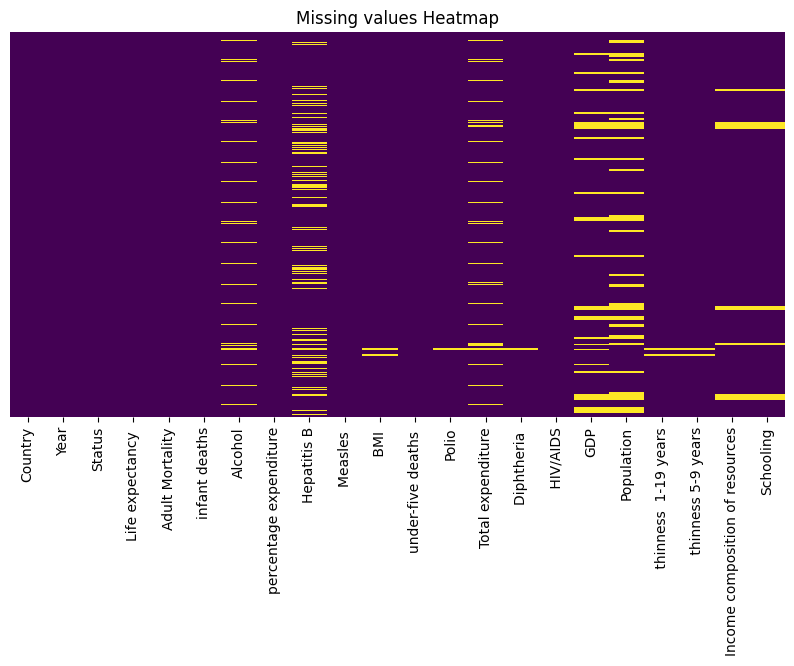

In [163]:
plt.figure(figsize=(10,5))
sns.heatmap(lir_df.isnull(), cbar = False, cmap='viridis', yticklabels=False)
plt.title('Missing values Heatmap')
plt.show()


### There are missing values in Hepatitis B , GDP, Population has missing value more than 15%
### there are colums with less than 8 percent which are Alcohol, BMI, Total expenditure, thinness 1-19 years, thinness 5-9 years , Income composition of resources
### GDP', 'Population' -- with this we can calculate the GDP per captia and use that as a feature.

### There are 10 missing values in the Life expectancy column so we are removing that values as it won't affect the prediction

In [164]:
lir_df = lir_df[lir_df['Life expectancy '].notnull()]

In [165]:
df = lir_df.groupby(['Country'])['Population'].mean().reset_index()
df.loc[df['Population'].isna()]

,Country,Population
4,Antigua and Barbuda,NaN
10,Bahamas,NaN
11,Bahrain,NaN
13,Barbados,NaN
19,Bolivia (Plurinational State of),NaN
23,Brunei Darussalam,NaN
37,Congo,NaN
40,Cuba,NaN
42,Czechia,NaN
43,Côte d'Ivoire,NaN


In [166]:
lir_df['Population'].skew()

15.909652757741815

### since there is a right kew we can fill the data with median values for population.

In [167]:
hep_miss_df = lir_df.loc[lir_df['Hepatitis B'].isna()]
hep_miss_df.groupby('Country')['Hepatitis B'].size()

Country
Algeria                                                  4
Angola                                                   7
Antigua and Barbuda                                      1
Argentina                                                2
Australia                                                1
Azerbaijan                                               2
Bahamas                                                  1
Bangladesh                                               3
Barbados                                                 1
Benin                                                    2
Bosnia and Herzegovina                                   4
Burkina Faso                                             6
Burundi                                                  4
Cabo Verde                                               2
Cambodia                                                 6
Cameroon                                                 5
Canada                                          

In [168]:
lir_df[lir_df['Country'] == 'Algeria'][['Year', 'Hepatitis B']]

,Year,Hepatitis B
32,2015,95.0
33,2014,95.0
34,2013,95.0
35,2012,95.0
36,2011,95.0
37,2010,95.0
38,2009,94.0
39,2008,91.0
40,2007,9.0
41,2006,8.0


In [169]:
missing_by_year = hep_miss_df[hep_miss_df['Hepatitis B'].isna()].groupby('Year').size()
print(missing_by_year)


Year
2000    98
2001    88
2002    70
2003    52
2004    45
2005    36
2006    32
2007    24
2008    20
2009    17
2010    15
2011    13
2012    13
2013    11
2014    10
2015     9
dtype: int64


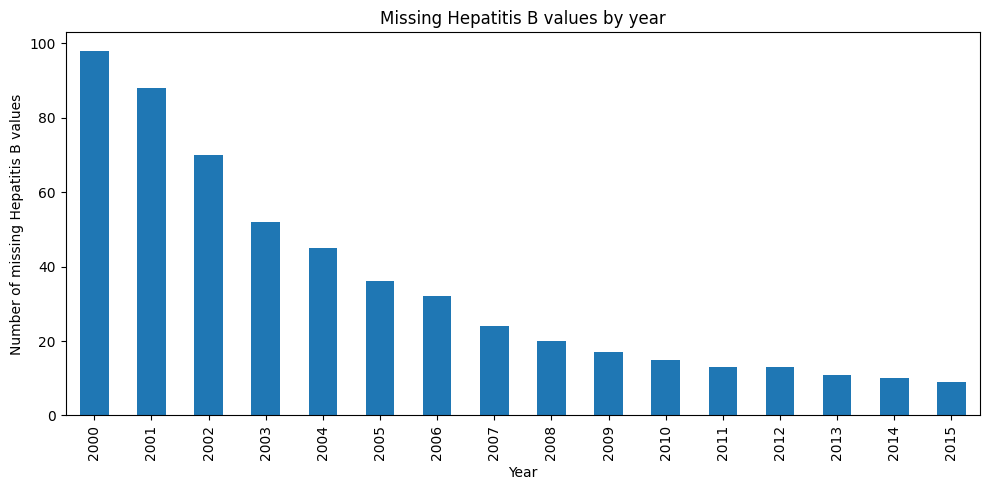

In [170]:
plt.figure(figsize=(10, 5))
missing_by_year.plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of missing Hepatitis B values')
plt.title('Missing Hepatitis B values by year')
plt.tight_layout()
plt.show()


<Axes: ylabel='Frequency'>

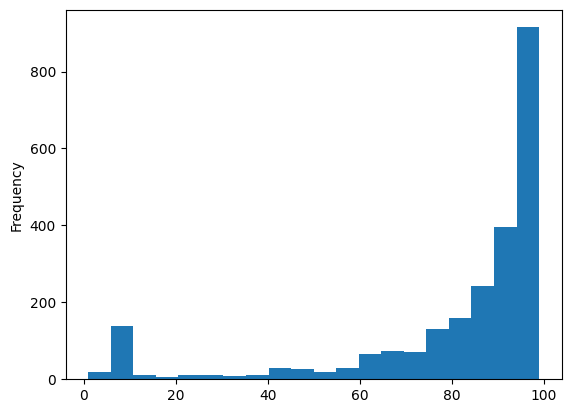

In [171]:
lir_df['Hepatitis B'].plot(
    kind= 'hist',
    bins = 20
)

In [172]:
lir_df['Hepatitis B'].skew()

-1.933773510510973

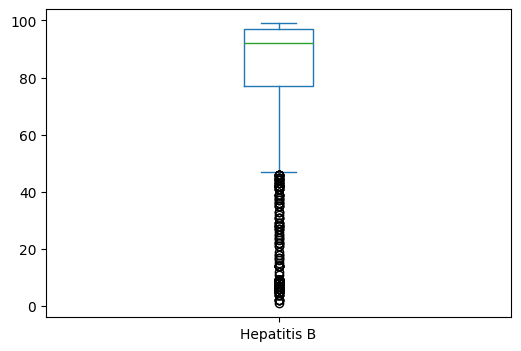

In [173]:
plt.figure(figsize=(6,4))
lir_df['Hepatitis B'].plot(kind='box')
plt.show()

In [174]:
print("Skewness:", lir_df['Hepatitis B'].skew())
print("Median:", lir_df['Hepatitis B'].median())
print("Mean:", lir_df['Hepatitis B'].mean())

Skewness: -1.933773510510973
Median: 92.0
Mean: 80.96084210526315


### Based on the above observation we can say that, In the early years there are more missing values gradually the missing values were reduced we can use the median based fill by grouping each country. and the some countries may have all values missing for that we can fill median based on country Status. even after this there are some NAN we can fill it with median. why we are using median as it is heavyly right skewed.

# GDP

In [175]:
gdp_na = lir_df.loc[lir_df['GDP'].isna()].reset_index()
gdp_na.head()

,index,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,160,Bahamas,2015,Developing,76.1,147.0,0,NaN,0.0,95.0,0,64.5,0,95.0,NaN,95.0,0.1,NaN,NaN,2.5,2.5,0.790,12.6
1,161,Bahamas,2014,Developing,75.4,16.0,0,9.45,0.0,96.0,0,63.8,0,96.0,7.74,96.0,0.1,NaN,NaN,2.5,2.5,0.789,12.6
2,162,Bahamas,2013,Developing,74.8,172.0,0,9.42,0.0,97.0,0,63.2,0,97.0,7.50,97.0,0.1,NaN,NaN,2.5,2.5,0.790,12.6
3,163,Bahamas,2012,Developing,74.9,167.0,0,9.50,0.0,96.0,0,62.6,0,99.0,7.43,98.0,0.2,NaN,NaN,2.5,2.5,0.789,12.6
4,164,Bahamas,2011,Developing,75.0,162.0,0,9.34,0.0,95.0,0,62.0,0,97.0,7.63,98.0,0.1,NaN,NaN,2.5,2.5,0.788,12.6


In [176]:
gdp_missing_country = (
    lir_df.groupby('Country')['GDP']
          .apply(lambda x: x.isna().sum())
          .sort_values(ascending=False)
)

gdp_missing_country.head(33)

Country
Gambia                                                  16
Micronesia (Federated States of)                        16
Congo                                                   16
Côte d'Ivoire                                           16
Democratic People's Republic of Korea                   16
Iran (Islamic Republic of)                              16
Democratic Republic of the Congo                        16
Republic of Moldova                                     16
The former Yugoslav republic of Macedonia               16
Egypt                                                   16
Slovakia                                                16
Bolivia (Plurinational State of)                        16
Kyrgyzstan                                              16
Lao People's Democratic Republic                        16
Czechia                                                 16
Saint Lucia                                             16
Saint Vincent and the Grenadines                

### So for some countries the missing values are low so what we can do is we can impute with central tendency. To select which to use we need to check outliers for hat column.

In [177]:
lir_df.groupby('Status')['GDP'].apply(lambda x: x.isna().mean())

Status
Developed     0.125000
Developing    0.156871
Name: GDP, dtype: float64

### Also we cannot say that missing values are not only from Developing countries it also from the Developed counties which indicates status is not an important factor

In [178]:
gdp_missing = lir_df['GDP'].isna()

lir_df.loc[gdp_missing, 'Population'].isna().mean()

0.9503386004514672

Before moving to the outlier detection we can see that where GDP is missing Population is also missing and wich cross vwerifying that we can see that there are 95% missing values of population where  gdp is also missing.

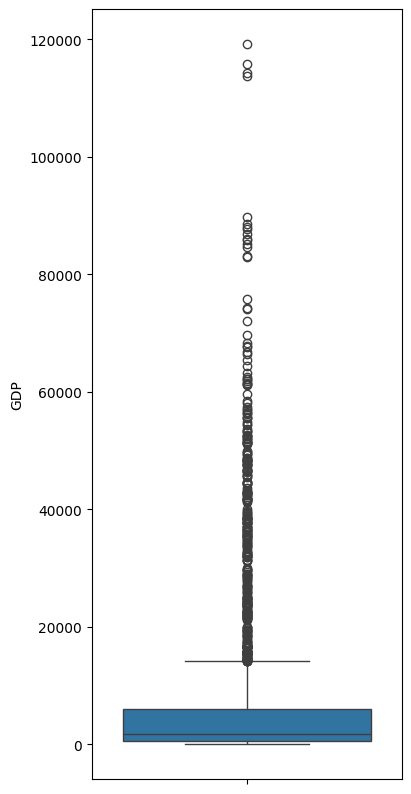

In [179]:
plt.figure(figsize=(4,10))
sns.boxplot(lir_df['GDP'])
plt.show()

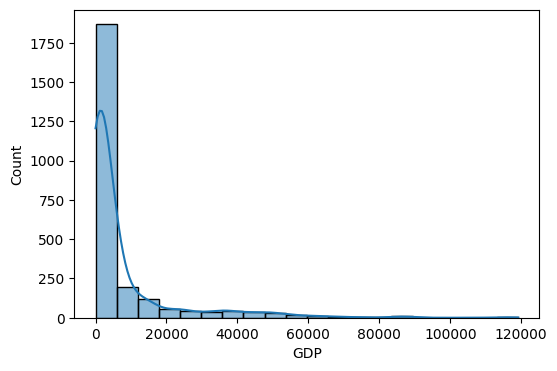

In [180]:
plt.figure(figsize=(6,4))
sns.histplot(
    data= lir_df,
    x = 'GDP',
    bins= 20,
    kde = True
)
plt.show()

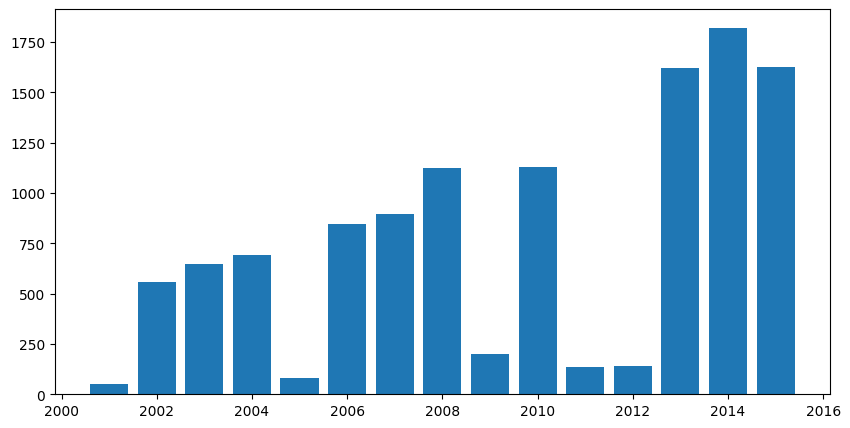

In [181]:
stap_df = lir_df.loc[
    lir_df['Country'] == 'Sao Tome and Principe', ['Year', 'GDP']
].reset_index(drop=True)
stap_df

plt.figure(figsize=(10,5))
plt.bar(x = stap_df['Year'], height = stap_df['GDP'])
plt.tight_layout
plt.show()


In [182]:
def country_yearwise_gdp(country_name):
        df = lir_df.loc[
        lir_df['Country'] == str(country_name), ['Year', 'GDP']
    ].reset_index(drop=True)
        print(df)
        plt.figure(figsize=(10,5))
        plt.bar(x = df['Year'], height = df['GDP'])
        plt.xticks(range(2000,2016))
        plt.tight_layout
        plt.show()


    Year          GDP
0   2015          NaN
1   2014          NaN
2   2013          NaN
3   2012          NaN
4   2011          NaN
5   2010          NaN
6   2009          NaN
7   2008          NaN
8   2007   258.352900
9   2006  1762.246170
10  2005  1577.457182
11  2004   148.852738
12  2003  1253.391430
13  2002  1263.134550
14  2001  1258.421953
15  2000  1177.629268


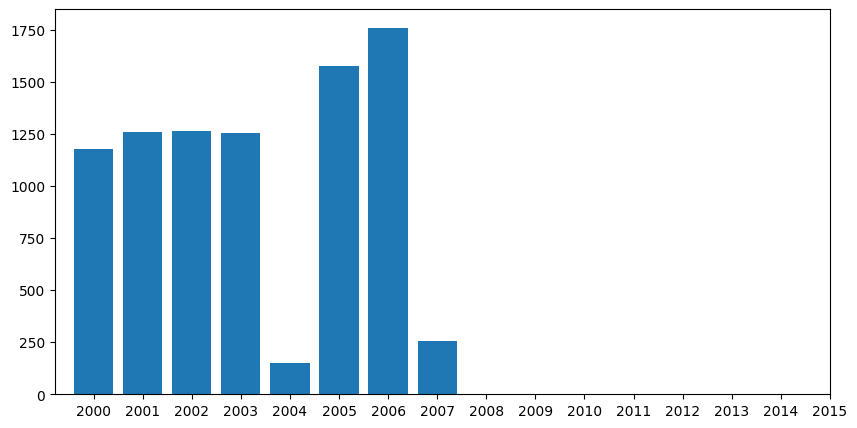

In [183]:
country_yearwise_gdp('Syrian Arab Republic')

    Year          GDP
0   2015  1624.639630
1   2014  1821.878734
2   2013  1619.532678
3   2012   138.949959
4   2011   134.326189
5   2010  1129.754961
6   2009   199.571460
7   2008  1126.462120
8   2007   894.927988
9   2006   843.894470
10  2005    81.861570
11  2004   693.345683
12  2003   649.342153
13  2002   555.818538
14  2001    51.216381
15  2000          NaN


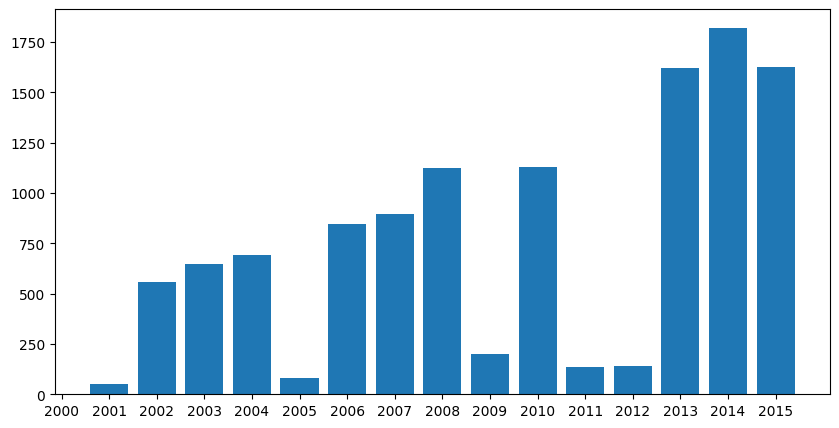

In [184]:
country_yearwise_gdp('Sao Tome and Principe')

    Year         GDP
0   2015  426.985370
1   2014  417.891430
2   2013   47.543235
3   2012         NaN
4   2011         NaN
5   2010         NaN
6   2009         NaN
7   2008         NaN
8   2007         NaN
9   2006         NaN
10  2005         NaN
11  2004         NaN
12  2003         NaN
13  2002         NaN
14  2001         NaN
15  2000         NaN


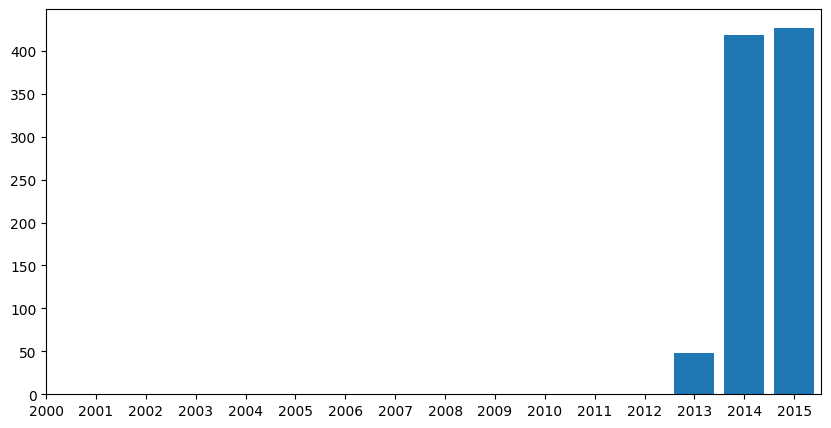

In [185]:
country_yearwise_gdp('Somalia')

### we can use iterative Imputation for the row where all the data points are missing where we can select the best independent variable for GDP and fill it but don't use Life Expectency as it can lead to data leakage. if there are one valid data point we can apply the constant Growth Back Casting Formula.  find the annual Real GDP Growth Rate (%) or Inflation Rate (%) figures for 2000–2015 
$$
GDP_{t-1} = \frac{GDP_t}{1 + \text{Growth Rate}_t + \text{Inflation Rate}_t}
$$

# Total expenditure  

In [186]:
td_df = lir_df.loc[lir_df['Total expenditure'].isnull()]
print(td_df.shape)
td_df.head()


(226, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
32,Algeria,2015,Developing,75.6,19.0,21,NaN,0.0,95.0,63,59.5,24,95.0,NaN,95.0,0.1,4132.762920,39871528.0,6.0,5.8,0.743,14.4
48,Angola,2015,Developing,52.4,335.0,66,NaN,0.0,64.0,118,23.3,98,7.0,NaN,64.0,1.9,3695.793748,2785935.0,8.3,8.2,0.531,11.4
64,Antigua and Barbuda,2015,Developing,76.4,13.0,0,NaN,0.0,99.0,0,47.7,0,86.0,NaN,99.0,0.2,13566.954100,NaN,3.3,3.3,0.784,13.9
80,Argentina,2015,Developing,76.3,116.0,8,NaN,0.0,94.0,0,62.8,9,93.0,NaN,94.0,0.1,13467.123600,43417765.0,1.0,0.9,0.826,17.3
96,Armenia,2015,Developing,74.8,118.0,1,NaN,0.0,94.0,33,54.9,1,96.0,NaN,94.0,0.1,369.654776,291695.0,2.1,2.2,0.741,12.7


In [187]:
te_missing_country = (
    lir_df.groupby('Country')['Total expenditure']
          .apply(lambda x: x.isna().sum())
          .sort_values(ascending=False)
)

te_missing_country

Country
Somalia                                                 16
Democratic People's Republic of Korea                   16
South Sudan                                             13
Iraq                                                     4
Peru                                                     1
Nigeria                                                  1
Norway                                                   1
Oman                                                     1
Pakistan                                                 1
Panama                                                   1
Papua New Guinea                                         1
Paraguay                                                 1
Lebanon                                                  1
Nicaragua                                                1
Philippines                                              1
Poland                                                   1
Portugal                                        

In [188]:
lir_df.loc[lir_df['Country'] == 'Peru']

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2007,Peru,2015,Developing,75.5,123.0,8,NaN,0.000000,9.0,4,55.6,10,88.0,NaN,9.0,0.1,63.343259,31376671.0,1.1,1.1,0.737,13.4
2008,Peru,2014,Developing,75.3,125.0,8,0.01,973.728675,88.0,0,54.9,10,78.0,5.47,88.0,0.1,6491.524500,3973354.0,1.1,1.1,0.735,13.4
2009,Peru,2013,Developing,75.3,125.0,8,5.38,946.652117,88.0,0,54.2,11,71.0,5.23,88.0,0.1,6583.116248,3565716.0,1.1,1.1,0.731,13.4
2010,Peru,2012,Developing,74.9,129.0,9,5.14,885.985819,95.0,0,53.6,11,94.0,5.18,95.0,0.1,6387.785281,3158966.0,1.1,1.1,0.725,13.4
2011,Peru,2011,Developing,74.5,133.0,9,4.83,759.538070,91.0,0,52.9,12,91.0,4.93,91.0,0.2,5771.565878,29759989.0,1.1,1.1,0.721,13.4
2012,Peru,2010,Developing,73.7,14.0,10,4.72,69.439345,93.0,0,52.2,12,92.0,5.30,93.0,0.2,522.493191,29373646.0,1.1,1.1,0.708,13.3
2013,Peru,2009,Developing,73.8,14.0,10,4.69,570.453247,93.0,0,51.5,13,92.0,5.36,93.0,0.3,4166.933870,29157.0,1.2,1.2,0.706,13.3
2014,Peru,2008,Developing,73.9,138.0,11,4.85,58.498974,93.0,1,5.8,14,93.0,4.73,93.0,0.3,428.878110,2864198.0,1.2,1.2,0.700,13.2
2015,Peru,2007,Developing,74.0,133.0,11,4.29,516.403702,93.0,0,5.2,15,93.0,4.60,93.0,0.3,3611.214700,28292724.0,1.2,1.2,0.696,13.2
2016,Peru,2006,Developing,74.2,134.0,12,4.22,448.767046,94.0,0,49.5,15,94.0,4.47,94.0,0.4,3171.498560,27949944.0,1.2,1.2,0.693,13.0


In [189]:
lir_df.loc[lir_df['Country'] == 'Niger']

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1877,Niger,2015,Developing,61.8,22.0,49,NaN,0.000000,65.0,7693,19.3,87,65.0,NaN,65.0,0.4,358.997310,19896965.0,9.6,9.4,0.351,5.4
1878,Niger,2014,Developing,61.4,223.0,49,0.01,3.304040,68.0,1142,18.9,88,67.0,5.82,68.0,0.5,43.646498,19148219.0,9.8,9.6,0.345,5.3
1879,Niger,2013,Developing,69.0,227.0,49,0.01,31.502432,67.0,1224,18.5,89,56.0,5.90,67.0,0.6,416.148380,18426372.0,1.0,9.9,0.341,5.3
1880,Niger,2012,Developing,63.0,232.0,49,0.01,29.755180,71.0,272,18.1,90,71.0,6.11,71.0,0.7,391.515524,17731634.0,1.3,1.1,0.331,5.1
1881,Niger,2011,Developing,59.4,241.0,50,0.15,32.224934,75.0,771,17.7,93,4.0,6.66,75.0,0.7,375.581987,1764636.0,1.5,1.3,0.323,4.8
1882,Niger,2010,Developing,58.2,252.0,50,0.12,5.883761,7.0,372,17.3,95,75.0,6.36,7.0,0.9,348.151511,16425578.0,1.7,1.6,0.312,4.5
1883,Niger,2009,Developing,57.1,263.0,51,0.11,5.665405,71.0,801,16.9,99,71.0,6.98,71.0,1.1,341.289462,15813913.0,11.0,1.8,0.307,4.2
1884,Niger,2008,Developing,56.0,272.0,52,0.12,40.378357,NaN,1317,16.5,102,68.0,6.76,67.0,1.3,354.818600,15228525.0,11.2,11.0,0.298,4.0
1885,Niger,2007,Developing,55.2,276.0,53,0.10,35.809297,NaN,282,16.1,106,57.0,6.94,57.0,1.4,292.559620,14668338.0,11.4,11.3,0.293,3.8
1886,Niger,2006,Developing,54.5,277.0,54,0.11,43.421931,NaN,59,15.7,110,52.0,7.39,51.0,1.5,258.463873,1413264.0,11.6,11.5,0.286,3.7


In [190]:
lir_df[lir_df['Year'] == 2015][['Country', 'Total expenditure']].reset_index(drop=True)

,Country,Total expenditure
0,Afghanistan,8.16
1,Albania,6.00
2,Algeria,NaN
3,Angola,NaN
4,Antigua and Barbuda,NaN
5,Argentina,NaN
6,Armenia,NaN
7,Australia,NaN
8,Austria,NaN
9,Azerbaijan,NaN


In [191]:
lir_df.groupby('Year')['Total expenditure'].count()

Year
2000    179
2001    179
2002    179
2003    180
2004    180
2005    180
2006    180
2007    180
2008    180
2009    180
2010    180
2011    180
2012    181
2013    181
2014    181
2015      2
Name: Total expenditure, dtype: int64

<Axes: ylabel='Frequency'>

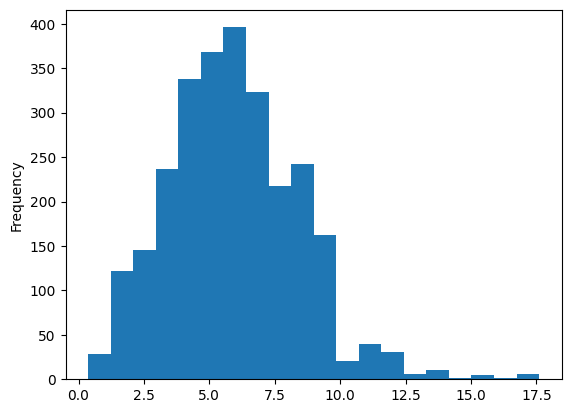

In [192]:
lir_df["Total expenditure"].plot(kind= 'hist', bins = 20)

In [193]:
lir_df["Total expenditure"].skew()

0.5772333235968542

### we can fill the total expenditure by country using ffill() which fill the previous valid value to the next null value because it is a time series column 

# ALCOHOL


In [194]:
alco_df = lir_df.loc[lir_df['Alcohol'].isna()]
alco_df.shape

(193, 22)

In [195]:
alco_df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
32,Algeria,2015,Developing,75.6,19.0,21,NaN,0.0,95.0,63,59.5,24,95.0,NaN,95.0,0.1,4132.762920,39871528.0,6.0,5.8,0.743,14.4
48,Angola,2015,Developing,52.4,335.0,66,NaN,0.0,64.0,118,23.3,98,7.0,NaN,64.0,1.9,3695.793748,2785935.0,8.3,8.2,0.531,11.4
64,Antigua and Barbuda,2015,Developing,76.4,13.0,0,NaN,0.0,99.0,0,47.7,0,86.0,NaN,99.0,0.2,13566.954100,NaN,3.3,3.3,0.784,13.9
80,Argentina,2015,Developing,76.3,116.0,8,NaN,0.0,94.0,0,62.8,9,93.0,NaN,94.0,0.1,13467.123600,43417765.0,1.0,0.9,0.826,17.3
96,Armenia,2015,Developing,74.8,118.0,1,NaN,0.0,94.0,33,54.9,1,96.0,NaN,94.0,0.1,369.654776,291695.0,2.1,2.2,0.741,12.7


In [196]:
alco_df.groupby('Country')['Alcohol'].size().sort_values(ascending=False) 
# As we can there is only one value missing majority of the countries except south sudan which has total column missing.

Country
South Sudan                                  16
Montenegro                                    2
Algeria                                       1
Netherlands                                   1
Niger                                         1
Nigeria                                       1
Oman                                          1
Pakistan                                      1
Panama                                        1
Papua New Guinea                              1
Paraguay                                      1
Peru                                          1
Philippines                                   1
Poland                                        1
Portugal                                      1
Qatar                                         1
Republic of Korea                             1
Republic of Moldova                           1
Romania                                       1
Russian Federation                            1
Rwanda                          

In [197]:
lir_df.groupby('Year')['Alcohol'].count()

Year
2000    182
2001    182
2002    182
2003    182
2004    182
2005    181
2006    182
2007    182
2008    182
2009    182
2010    182
2011    182
2012    182
2013    182
2014    182
2015      6
Name: Alcohol, dtype: int64

In [198]:
lir_df['Country'].nunique()

183

0.5872759823338338


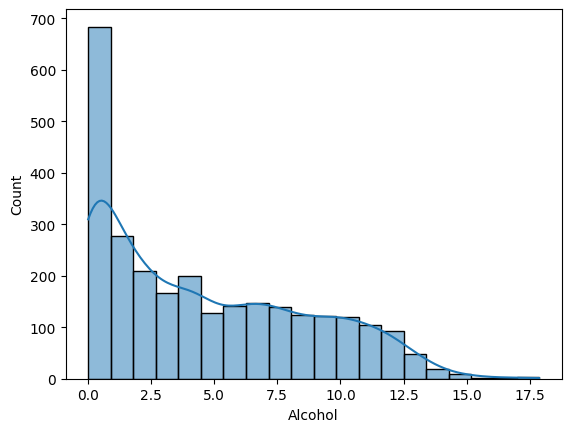

In [199]:
print(lir_df['Alcohol'].skew())
sns.histplot(x = lir_df['Alcohol'], bins= 20, kde= True)
plt.show()

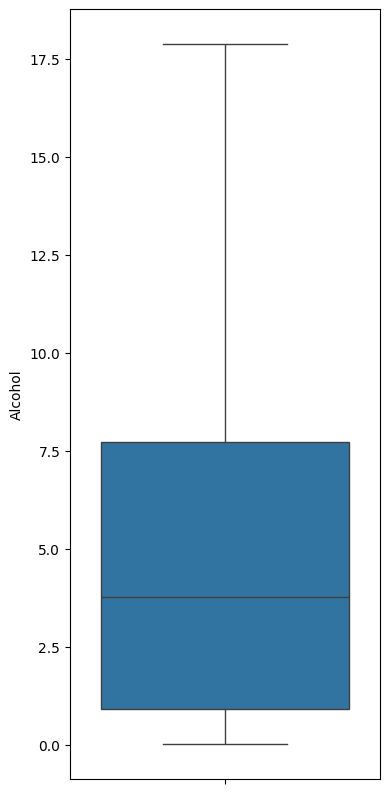

In [200]:
plt.figure(figsize=(4,10))
sns.boxplot(lir_df['Alcohol'])
plt.show()

In [201]:
import random
def alco_trend():
    countries = lir_df['Country'].unique().tolist()
    countries = random.sample(countries, 4)

    
    for country in countries:
        df =  lir_df.loc[lir_df['Country'] == country, ['Alcohol', 'Year']].reset_index(drop=True)
        plt.figure(figsize=(10,5))
        plt.bar(x = df['Year'], height= df['Alcohol'])
        plt.xticks(range(2000,2016))
        plt.tight_layout
        plt.title(f'Alcohol Level for each Year from 2000 to 2016 - {country}')
        plt.xlabel('Year')
        plt.ylabel('Alcohol')
        plt.show()
    
    

In [202]:
lir_df[lir_df['Alcohol'].isna()]['Year'].value_counts().sort_index()

Year
2000      1
2001      1
2002      1
2003      1
2004      1
2005      2
2006      1
2007      1
2008      1
2009      1
2010      1
2011      1
2012      1
2013      1
2014      1
2015    177
Name: count, dtype: int64

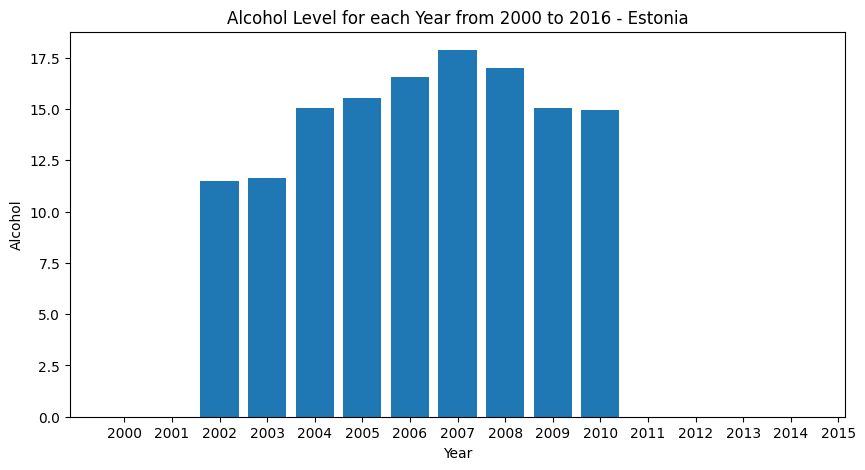

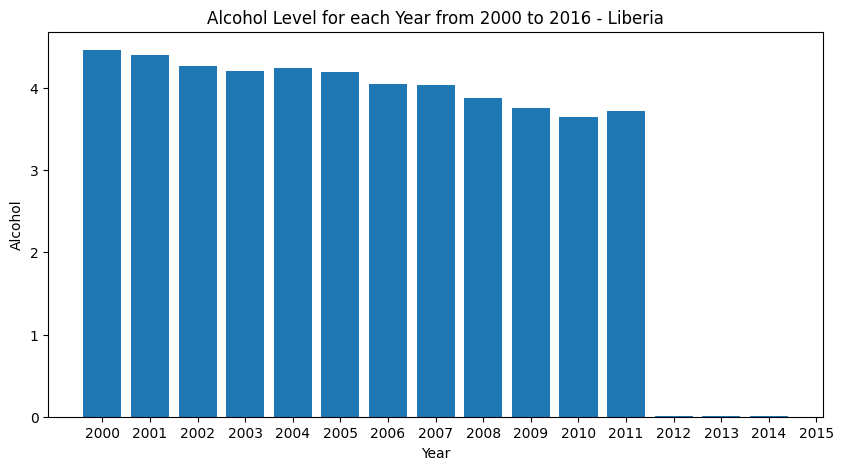

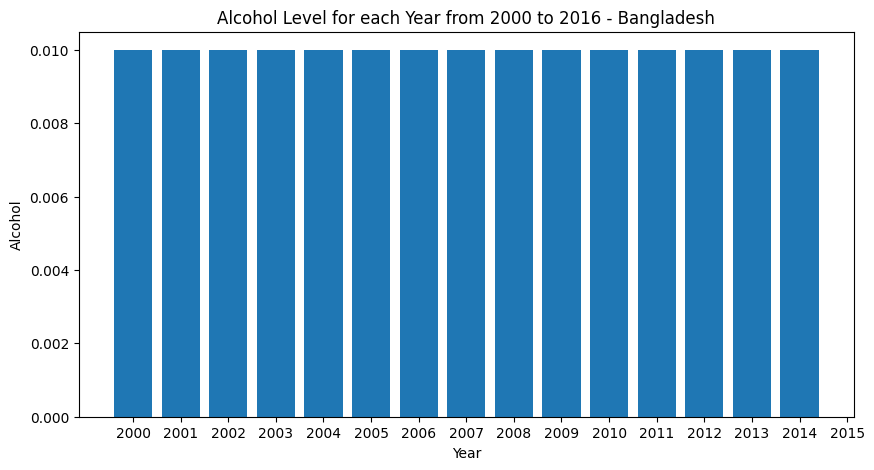

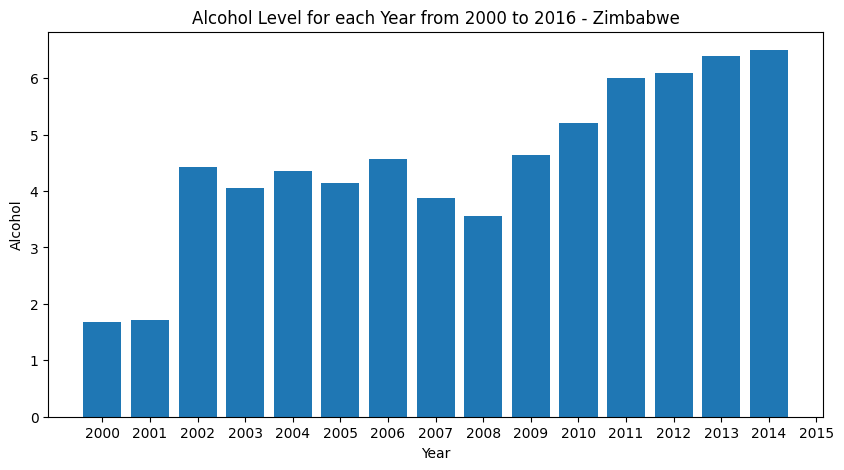

In [203]:
alco_trend()

In [204]:
lir_df.loc[lir_df['Country'] == 'Mauritius', ['Year', 'Alcohol']]

,Year,Alcohol
1667,2015,NaN
1668,2014,0.01
1669,2013,0.01
1670,2012,0.01
1671,2011,3.03
1672,2010,2.95
1673,2009,2.83
1674,2008,2.49
1675,2007,3.24
1676,2006,3.73


In [205]:
lir_df.loc[lir_df['Country'] == 'Benin', ['Year', 'Alcohol']]

,Year,Alcohol
272,2015,NaN
273,2014,0.01
274,2013,0.01
275,2012,0.01
276,2011,1.40
277,2010,1.33
278,2009,1.16
279,2008,1.28
280,2007,1.12
281,2006,1.19


In [206]:
(lir_df['Alcohol'] == 0.01).sum()

280

In [207]:
lir_df[lir_df['Alcohol'] == 0.01].groupby('Country')['Year'].apply(list)

Country
Afghanistan                              [2015, 2014, 2013, 2012, 2011, 2010, 2009, 200...
Algeria                                                                             [2014]
Azerbaijan                                                                    [2014, 2012]
Bangladesh                               [2014, 2013, 2012, 2011, 2010, 2009, 2008, 200...
Benin                                                                   [2014, 2013, 2012]
Bhutan                                                                  [2014, 2013, 2012]
Botswana                                                                [2014, 2013, 2012]
Brunei Darussalam                                                       [2014, 2013, 2012]
Burkina Faso                                                                        [2014]
Burundi                                                                 [2014, 2013, 2012]
Cabo Verde                                                              [2014, 201

In [208]:
lir_df[lir_df['Alcohol'] == 0.01]['Year'].value_counts().sort_index()

Year
2000     8
2001    10
2002     8
2003     8
2004     7
2005     6
2006     5
2007     3
2008     3
2009     5
2010     6
2011     8
2012    58
2013    57
2014    87
2015     1
Name: count, dtype: int64

### So out of 183 countries there are only 6 values are there in 2015 for each country except south sudan which has the entire Alcohol data missing and 181 values are there in the country Montenegro. also we have columns with 0.01 Alcohol Some counties have all years as low and those countries have stict no Alcohol policies and they are ligit but some countries have for last 2 year and Last 3 years so for that we it is inconsistant value and needed to assumed as null values so it also needs imputation.

### imputation
- Null the cell which has that 0.01 where the previous 3 years are 0.01
- As we can see the pattern the bar chart that the Alcohol consumption values are not varies drastically so we can fill it with the value before the null as it is a Time series data so we can use ffill here.
- Distirbution of the data is skewed so we need to do transformation but there are near zero values in some counties (0.01) where log transformations shinks the values so we can use squared root transformation.
- for south sudan if the model handles nulls we can keep it as NAN or we can use KNN imputator for LR , RF DT


# Income composition of resources

In [209]:
icor_df = lir_df.loc[lir_df['Income composition of resources'].isnull()]
icor_df.shape

(160, 22)

In [210]:
icor_df.groupby(['Country'])['Income composition of resources'].size()

Country
Czechia                                                 16
Côte d'Ivoire                                           16
Democratic People's Republic of Korea                   16
Democratic Republic of the Congo                        16
Republic of Korea                                       16
Republic of Moldova                                     16
Somalia                                                 16
United Kingdom of Great Britain and Northern Ireland    16
United Republic of Tanzania                             16
United States of America                                16
Name: Income composition of resources, dtype: int64

-1.142141952852178


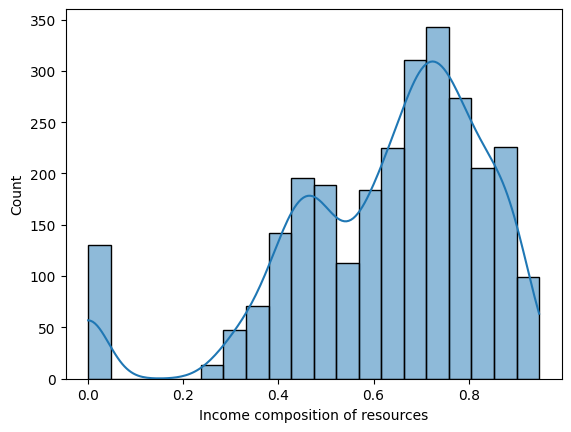

In [211]:
print(lir_df['Income composition of resources'].skew())
sns.histplot(x = lir_df['Income composition of resources'], bins= 20, kde= True)
plt.show()

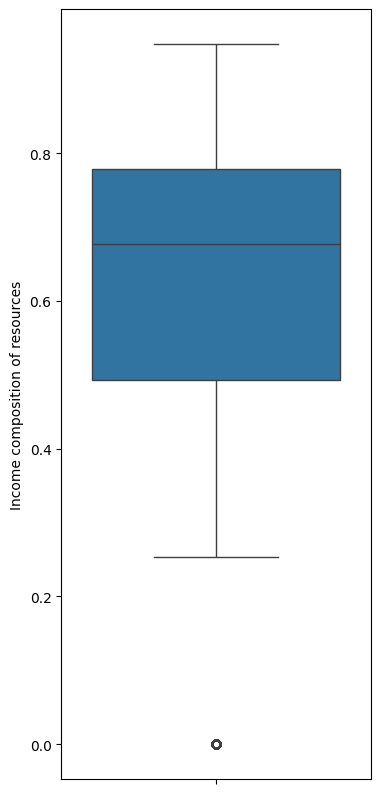

In [212]:
plt.figure(figsize=(4,10))
sns.boxplot(lir_df['Income composition of resources'])
plt.show()

In [213]:
lir_df[lir_df["Income composition of resources"] == 0][
    ["Country", "Year", "Income composition of resources"]
]

,Country,Year,Income composition of resources
74,Antigua and Barbuda,2005,0.0
75,Antigua and Barbuda,2004,0.0
76,Antigua and Barbuda,2003,0.0
77,Antigua and Barbuda,2002,0.0
78,Antigua and Barbuda,2001,0.0
79,Antigua and Barbuda,2000,0.0
175,Bahamas,2000,0.0
293,Bhutan,2010,0.0
294,Bhutan,2009,0.0
295,Bhutan,2008,0.0


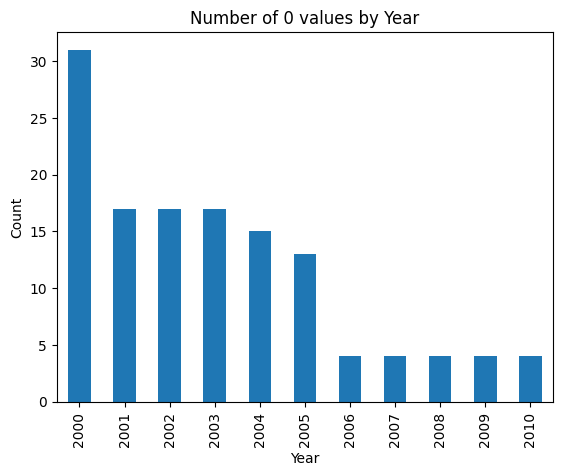

In [214]:
(
    lir_df[lir_df["Income composition of resources"] == 0]
    .groupby("Year")
    .size()
    .plot(kind="bar")
)

plt.ylabel("Count")
plt.title("Number of 0 values by Year")
plt.show()

In [215]:
zero_summary = (
    lir_df[lir_df["Income composition of resources"] == 0]
    .groupby(["Country", 'Status'])
    .agg({
        "GDP":"mean",
        "Life expectancy ":"mean",
        "Schooling":"mean"
    })
    .sort_values("GDP")
)

zero_summary

,,GDP,Life expectancy,Schooling
Country,Status,,,
Ethiopia,Developing,123.876257,51.200000,3.900000
Chad,Developing,166.231785,47.600000,4.700000
Equatorial Guinea,Developing,172.684910,52.700000,0.000000
Eritrea,Developing,177.013448,56.533333,4.616667
Burkina Faso,Developing,206.566307,52.550000,3.750000
Madagascar,Developing,245.939659,57.900000,8.000000
Guinea-Bissau,Developing,252.259860,52.966667,7.216667
Timor-Leste,Developing,422.286330,58.700000,0.000000
Nigeria,Developing,425.758349,47.575000,7.850000


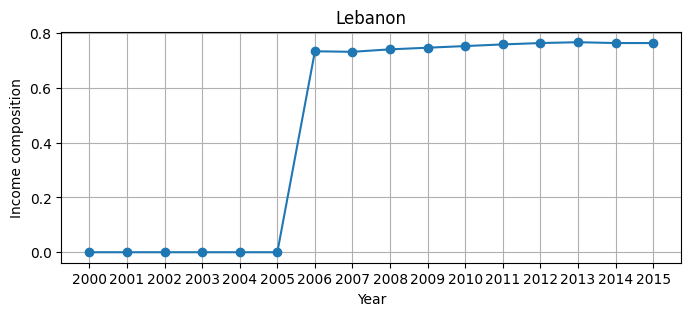

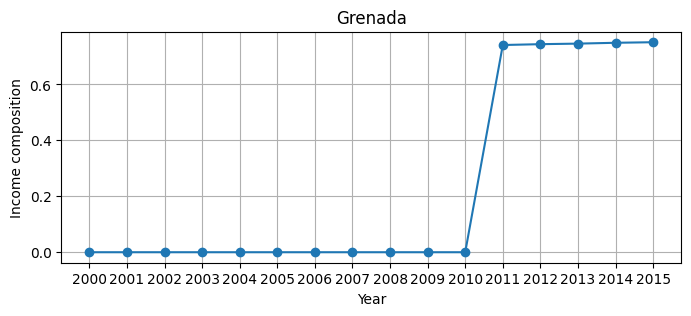

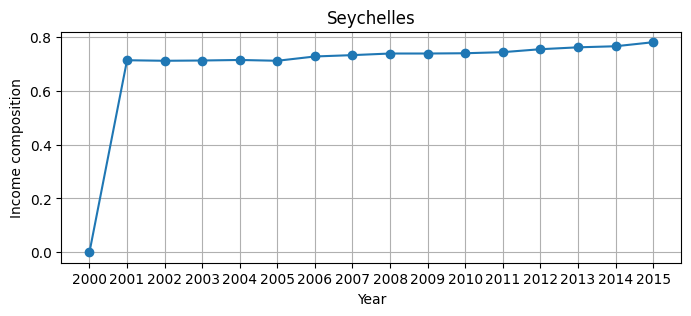

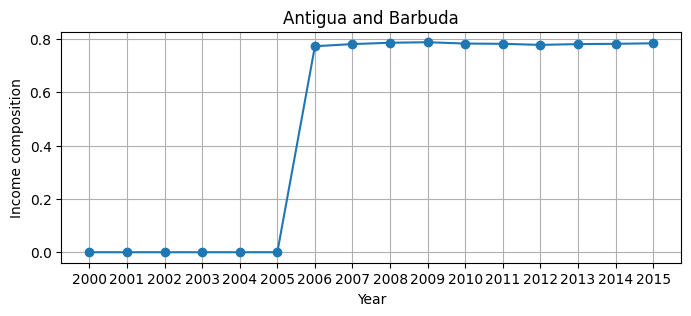

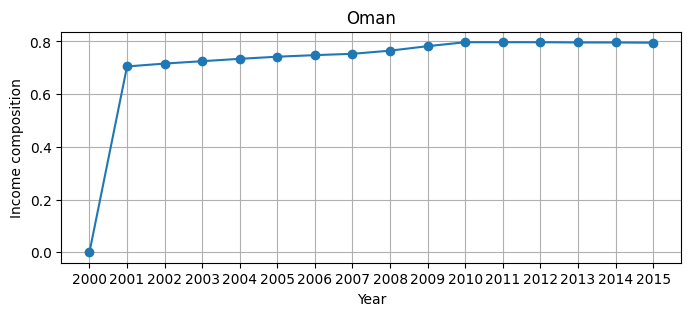

In [216]:
countries = [
    "Lebanon",
    "Grenada",
    "Seychelles",
    "Antigua and Barbuda",
    "Oman"
]

for country in countries:
    temp = lir_df[lir_df["Country"] == country]

    plt.figure(figsize=(8, 3))
    plt.plot(
        temp["Year"],
        temp["Income composition of resources"],
        marker="o"
    )
    plt.title(country)
    plt.xlabel("Year")
    plt.ylabel("Income composition")
    plt.xticks(range(2000, 2016))
    plt.grid(True)
    plt.show()

In [217]:
# Replacing the 0 values as Nulls 
lir_df["Income composition of resources"] = (
    lir_df["Income composition of resources"]
    .replace(0, np.nan)
)

-0.36128363485805126
Status
Developed    -0.498490
Developing   -0.318193
Name: Income composition of resources, dtype: float64


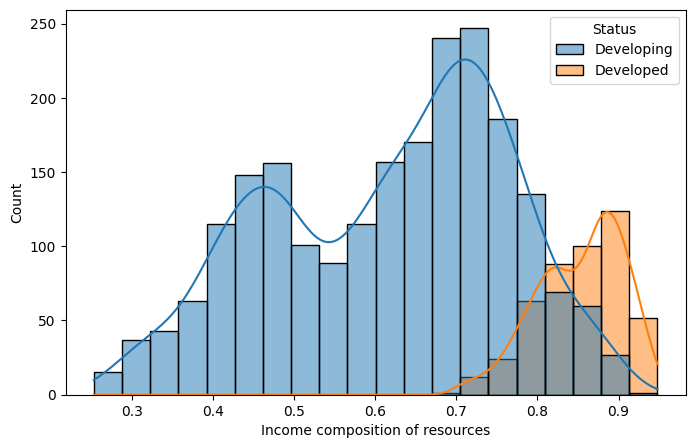

In [218]:
plt.figure(figsize=(8,5))
print(lir_df['Income composition of resources'].skew())
print(lir_df.groupby("Status")["Income composition of resources"].skew())
sns.histplot(
    data=lir_df,
    x="Income composition of resources",
    hue="Status",
    kde=True,
    bins=20
)

plt.show()

### We can see that all the years values are missing for these countries , we cannot use  median as the Income composition of resources won't be same for the USA and Somalia. so what we can do Regression-based imputation (Iterative Imputer) as this column should depend on the other columns like GDP, Schooling etc. from futher investigation we can see that the there are values in 0 which is not true and when we plot the series of data based on the years we observed that there is a sudden increase in the Income compostion resources which is also not possible therefore these zero values will be treated as null values. which will also be imputed with Iterative Imputer. As the values are from 0 to 1 , tranformation is not needed.

# SCHOOLING

In [219]:
school_df = lir_df.loc[lir_df['Schooling'].isna()]
print(school_df.shape)
school_df.head()

(160, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
432,Côte d'Ivoire,2015,Developing,53.3,397.0,57,NaN,0.0,83.0,65,28.0,79,81.0,NaN,83.0,1.9,NaN,NaN,5.5,5.5,NaN,NaN
433,Côte d'Ivoire,2014,Developing,52.8,47.0,58,0.01,0.0,76.0,50,27.4,80,76.0,5.72,76.0,2.0,NaN,NaN,5.6,5.6,NaN,NaN
434,Côte d'Ivoire,2013,Developing,52.3,412.0,59,3.15,0.0,8.0,48,26.8,81,79.0,5.81,8.0,2.4,NaN,NaN,5.8,5.7,NaN,NaN
435,Côte d'Ivoire,2012,Developing,52.0,415.0,59,3.24,0.0,82.0,137,26.2,82,83.0,6.14,82.0,2.9,NaN,NaN,5.9,5.9,NaN,NaN
436,Côte d'Ivoire,2011,Developing,51.7,419.0,60,3.13,0.0,62.0,628,25.6,83,58.0,6.42,62.0,3.3,NaN,NaN,6.1,6.0,NaN,NaN


In [220]:
school_df.groupby('Country')['Schooling'].size()

Country
Czechia                                                 16
Côte d'Ivoire                                           16
Democratic People's Republic of Korea                   16
Democratic Republic of the Congo                        16
Republic of Korea                                       16
Republic of Moldova                                     16
Somalia                                                 16
United Kingdom of Great Britain and Northern Ireland    16
United Republic of Tanzania                             16
United States of America                                16
Name: Schooling, dtype: int64

-0.5838842686144311
Status
Developed     0.382849
Developing   -0.834402
Name: Schooling, dtype: float64


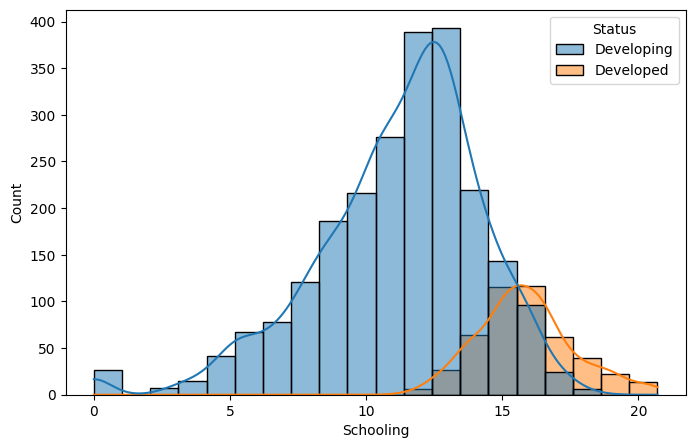

In [221]:
plt.figure(figsize=(8,5))
print(lir_df['Schooling'].skew())
print(lir_df.groupby("Status")["Schooling"].skew())
sns.histplot(
    data=lir_df,
    x="Schooling",
    hue="Status",
    kde=True,
    bins=20
)

plt.show()

### From the above plot and table we can see that the data is missing for all the years in the schooling for those countries so we are using Iterative Imputer for algorithms that does not handle Null values. Transformation is not need as the feature only slightly skewed.

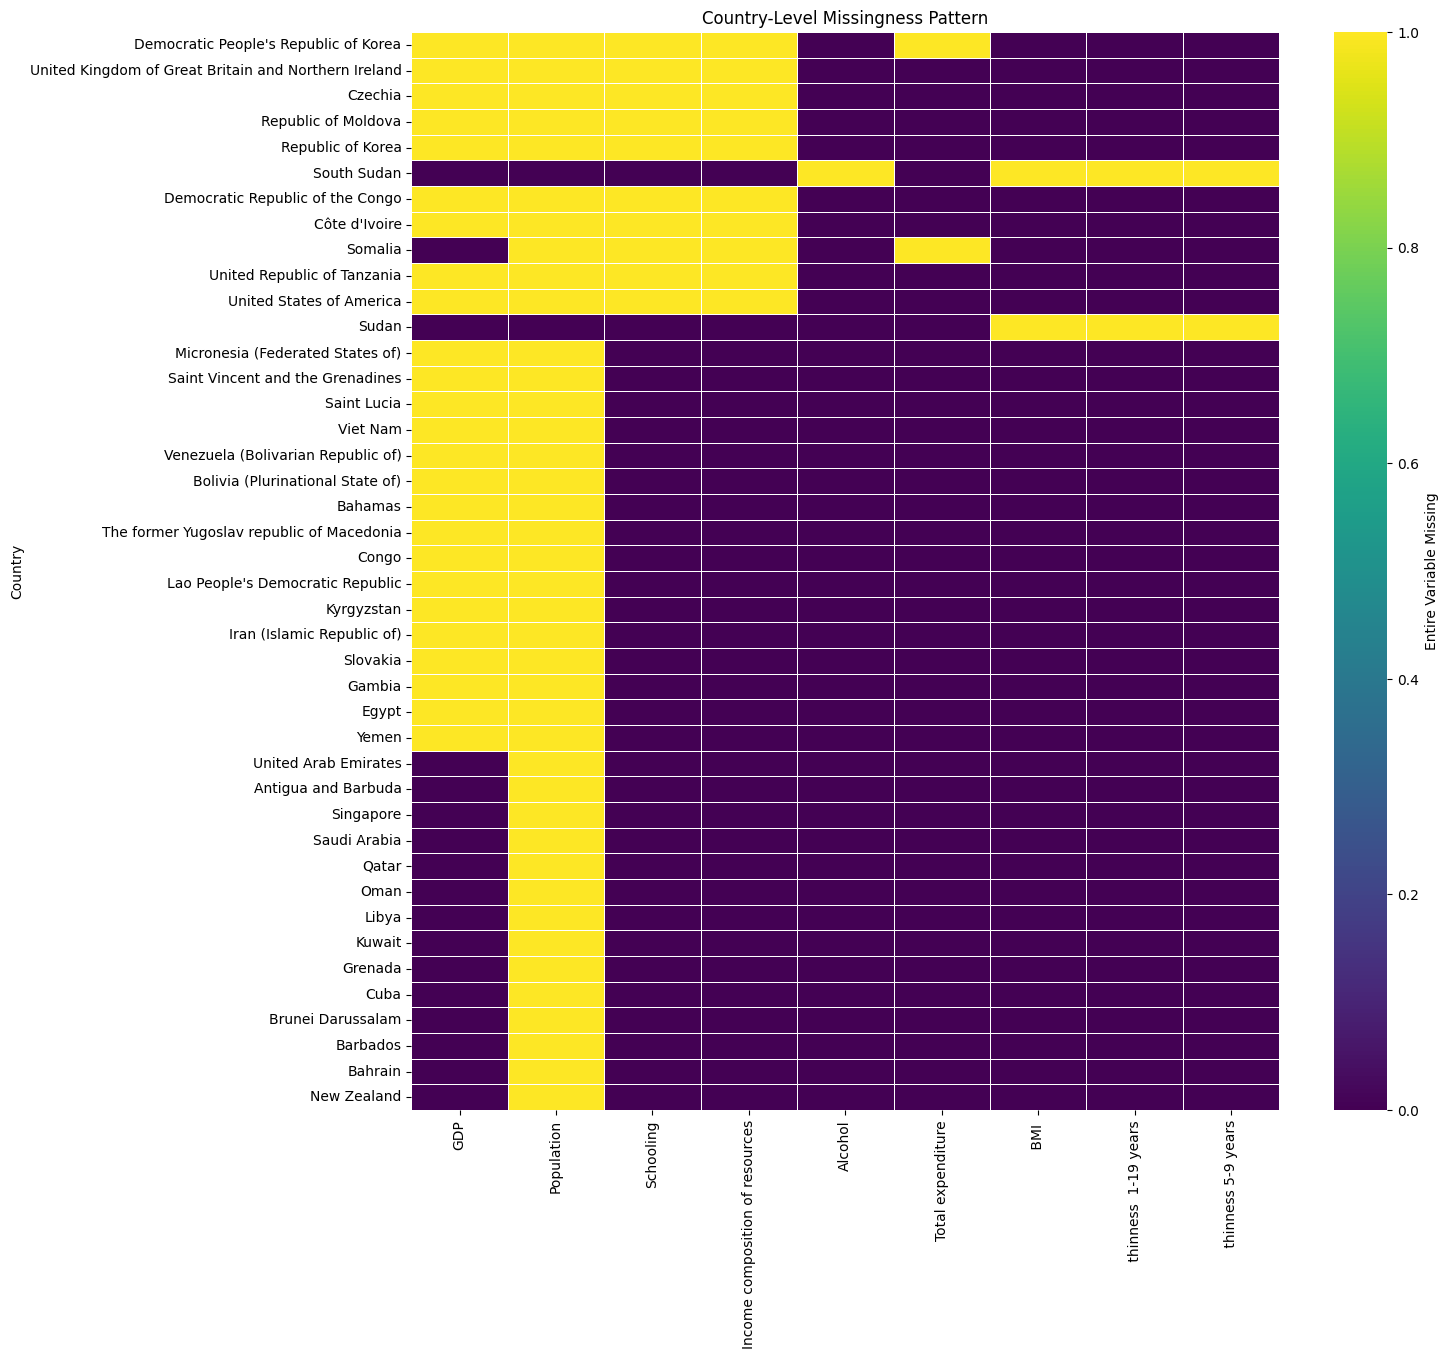

In [222]:
cols = [
    'GDP',
    'Population',
    'Schooling',
    'Income composition of resources',
    'Alcohol',
    'Total expenditure',
    ' BMI ',
    ' thinness  1-19 years',
    ' thinness 5-9 years' 
    
]
country_missing = (
    lir_df.groupby("Country")[cols]
          .apply(lambda x: x.isnull().all())
)

country_missing["Missing Variables"] = country_missing.sum(axis=1)

country_missing = (
    country_missing[country_missing["Missing Variables"] > 0]
    .sort_values("Missing Variables", ascending=False)
)
plt.figure(figsize=( 14, 14))
sns.heatmap(
    country_missing.drop(columns="Missing Variables"),
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Entire Variable Missing"}
)

plt.title("Country-Level Missingness Pattern")
plt.show()

### After analyzing the major missing columns we have identified the missingness is based on the countries so for that each imputation stragy was derived.

| Variable           | Recommended method                                    | Reason                         |
| ------------------ | ----------------------------------------------------- | ------------------------------ |
| GDP                | IterativeImputer                                      | Entire countries missing       |
| Population         | IterativeImputer                                      | Entire countries missing       |
| Schooling          | IterativeImputer                                      | Entire countries missing       |
| Income composition | IterativeImputer                                      | Entire countries missing       |
| Alcohol            | Forward fill (after replacing suspicious 0.01 values) | Mostly time-series missingness |
| Total expenditure  | Forward fill                                          | Mostly 2015 missing            |


# Less than 2% missing columns

# BMI

In [223]:
bmi_df = lir_df.loc[lir_df[' BMI '].isna()]
bmi_df.shape

(32, 22)

In [224]:
bmi_df.groupby('Country')[' BMI '].size()

Country
South Sudan    16
Sudan          16
Name:  BMI , dtype: int64

In [225]:
lir_df.groupby(['Status', 'Year'])[' BMI '].mean()

Status      Year
Developed   2000    45.581250
            2001    48.950000
            2002    52.315625
            2003    49.487500
            2004    50.031250
            2005    49.731250
            2006    51.940625
            2007    52.465625
            2008    55.518750
            2009    54.353125
            2010    54.859375
            2011    55.393750
            2012    50.846875
            2013    49.690625
            2014    51.903125
            2015    55.793750
Developing  2000    32.028859
            2001    33.383893
            2002    33.844966
            2003    33.638255
            2004    33.681879
            2005    32.574497
            2006    34.440268
            2007    33.651678
            2008    34.511409
            2009    36.411409
            2010    35.003356
            2011    36.511409
            2012    37.791275
            2013    39.018792
            2014    38.695973
            2015    39.953691
Name:  BMI , dtype: flo

<Axes: >

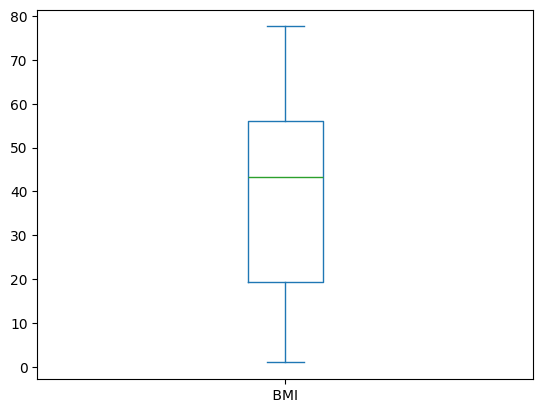

In [226]:
lir_df[' BMI '].plot(kind= 'box')

In [227]:
lir_df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [228]:
from scipy.stats import mannwhitneyu
import pandas as pd


columns = [
    "Schooling",
    "Life expectancy ",
    "Income composition of resources",
    "GDP",
    " thinness  1-19 years",
    "Adult Mortality",
    " BMI ",
    "Alcohol",
    "Polio",
    "Diphtheria ",
    "Total expenditure",
    "percentage expenditure",
    "Hepatitis B",
    "Population",
    " HIV/AIDS",
    "Measles ",
    "infant deaths",
    "under-five deaths "
]
lir_df["BMI_Group"] = np.where(
    lir_df[" BMI "] < 40,
    "Low BMI",
    "High BMI"
)

lir_df.groupby("BMI_Group")[columns].agg(["mean","median"])

results = []

for col in columns:
    low = lir_df.loc[lir_df["BMI_Group"] == "Low BMI", col].dropna()
    high = lir_df.loc[lir_df["BMI_Group"] == "High BMI", col].dropna()

    stat, p = mannwhitneyu(low, high)

    results.append({
        "Variable": col.strip(),
        "Low BMI Mean": low.mean(),
        "High BMI Mean": high.mean(),
        "Statistic": stat,
        "P-value": p
    })

results_df = (
    pd.DataFrame(results)
      .sort_values("P-value")
)

results_df

,Variable,Low BMI Mean,High BMI Mean,Statistic,P-value
6,BMI,1.927200e+01,5.537850e+01,0.0,0.000000e+00
4,thinness 1-19 years,7.415273e+00,2.532150e+00,1732196.5,4.806476e-205
2,Income composition of resources,5.511257e-01,7.479422e-01,271574.0,2.241339e-202
1,Life expectancy,6.349091e+01,7.430174e+01,377488.5,8.867941e-201
0,Schooling,1.018190e+01,1.354295e+01,342261.5,8.593733e-186
14,HIV/AIDS,3.305091e+00,3.688345e-01,1637875.5,2.984497e-176
17,under-five deaths,8.068364e+01,8.088216e+00,1616943.5,1.407541e-130
16,infant deaths,5.745382e+01,6.461043e+00,1595819.5,1.843428e-121
3,GDP,3.431354e+03,1.103964e+04,380898.0,1.498619e-104
5,Adult Mortality,2.171302e+02,1.184610e+02,1533467.0,1.596463e-92


### The BMI variable exhibited a clear bimodal distribution. Further investigation showed that this pattern persisted across all years, indicating that it was not caused by temporal variation. Although developed countries were primarily concentrated in the higher BMI mode, developing countries continued to display two distinct peaks, suggesting that development status alone did not explain the bimodality. Statistical comparisons between the two BMI groups revealed significant differences in schooling, life expectancy, income composition of resources, GDP, child thinness, HIV/AIDS prevalence, and mortality indicators. These findings indicate that the bimodal distribution reflects the coexistence of two distinct socioeconomic and public health profiles within the dataset rather than being attributable to a single explanatory variable.
### We can replace the missing values with the ITERATIVE imputation but use only the columns like schooling . life expectency, Income composition , thinness , infant deaths , adult mortality and HIV/AIDs.

# thinness  1-19 years

In [229]:
thinness119years_df = lir_df.loc[lir_df[' thinness  1-19 years'].isna()]
thinness119years_df.shape

(32, 23)

In [230]:
thinness119years_df.groupby('Country')[' thinness  1-19 years'].size()

Country
South Sudan    16
Sudan          16
Name:  thinness  1-19 years, dtype: int64

In [231]:
lir_df[' thinness  1-19 years'].median()

3.3

<Axes: >

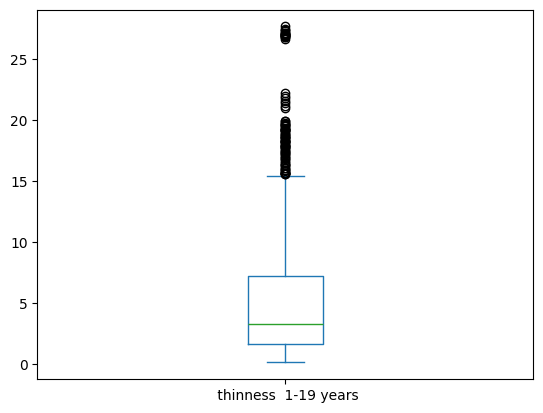

In [232]:
lir_df[' thinness  1-19 years'].plot(kind= 'box')

1.710626013574815


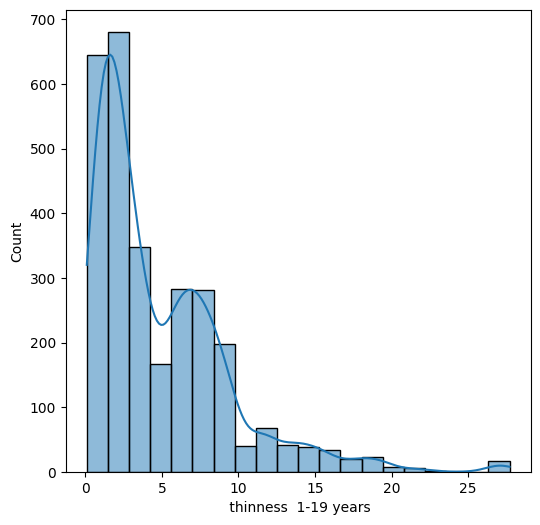

In [233]:
print(lir_df[' thinness  1-19 years'].skew())
plt.figure(figsize=(6,6))
sns.histplot(
    x = lir_df[' thinness  1-19 years'],
    kde= True,
    bins= 20
)
plt.show()

### Same as BMI use iterative imputation.

# thinness 5-9 years

In [234]:
thinness59years_df = lir_df.loc[lir_df[' thinness 5-9 years'].isna()]
thinness59years_df.shape

(32, 23)

In [235]:
thinness59years_df.groupby('Country')[' thinness 5-9 years'].size()

Country
South Sudan    16
Sudan          16
Name:  thinness 5-9 years, dtype: int64

1.776590740902215


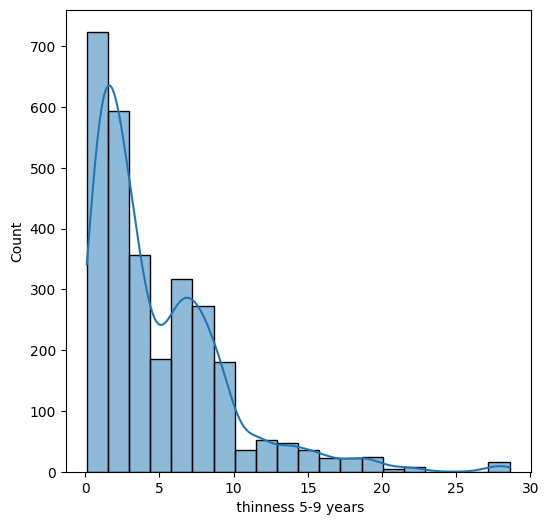

In [236]:
print(lir_df[' thinness 5-9 years'].skew())
plt.figure(figsize=(6,6))
sns.histplot(
    x = lir_df[' thinness 5-9 years'],
    kde= True,
    bins= 20
)
plt.show()

### We can replace the missing values with same as BMI use iterative imputation.

In [237]:
lir_df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling', 'BMI_Group'],
      dtype='object')

In [238]:
na_polio = lir_df.loc[lir_df['Polio'].isnull()]
na_polio.shape

(19, 23)

In [239]:
na_polio.groupby('Country')['Polio'].size()

Country
Montenegro      6
South Sudan    11
Timor-Leste     2
Name: Polio, dtype: int64

-2.097958050876243


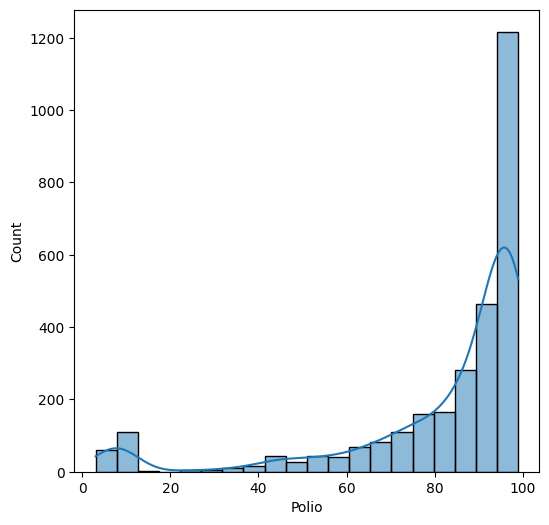

In [240]:
print(lir_df['Polio'].skew())
plt.figure(figsize=(6,6))
sns.histplot(
    x = lir_df['Polio'],
    kde= True,
    bins= 20
)
plt.show()

<Axes: >

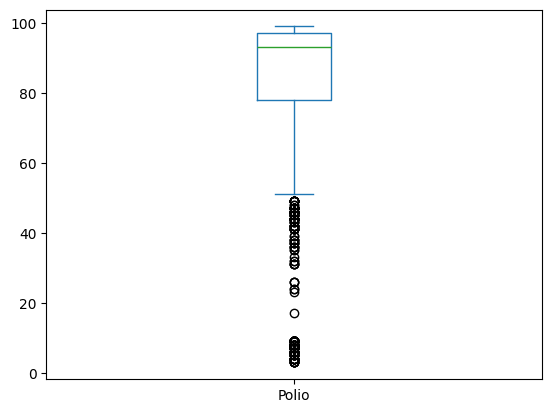

In [241]:
lir_df['Polio'].plot(kind= 'box')

In [242]:
lir_df['Polio'].describe()

count    2909.000000
mean       82.548298
std        23.416674
min         3.000000
25%        78.000000
50%        93.000000
75%        97.000000
max        99.000000
Name: Polio, dtype: float64

In [243]:
lir_df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,BMI_Group
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,Low BMI
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,Low BMI
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,Low BMI
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,Low BMI
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,Low BMI
